In [48]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [49]:
# Load the data
df = pd.read_csv('Customer_Churn.csv')

## Data Cleaning


In [50]:
# Check rows and columns
df.shape

(7043, 21)

In [51]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [53]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [54]:
# check missing values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [55]:
# Changing the column name in snake case 

df.columns = df.columns.str.lower()

df = df.rename(columns={
    'customerid': 'customer_id',
    'gender': 'gender',
    'seniorcitizen': 'senior_citizen',
    'partner': 'partner',
    'dependents': 'dependents',
    'tenure': 'tenure',
    'phoneservice': 'phone_service',
    'multiplelines': 'multiple_lines',
    'internetservice': 'internet_service',
    'onlinesecurity': 'online_security',
    'onlinebackup': 'online_backup',
    'deviceprotection': 'device_protection',
    'techsupport': 'tech_support',
    'streamingtv': 'streaming_tv',
    'streamingmovies': 'streaming_movies',
    'contract': 'contract',
    'paperlessbilling': 'paperless_billing',
    'paymentmethod': 'payment_method',
    'monthlycharges': 'monthly_charges',
    'totalcharges': 'total_charges',
    'churn': 'churn'
})

df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='str')

In [56]:
# Drop customerID 
df = df.drop('customer_id', axis=1)

In [57]:
df.shape[1]

20

In [58]:
# change the data types total charges
df['total_charges'] = df['total_charges'].astype(str).str.strip()

In [59]:
df['total_charges'].dtype

<StringDtype(na_value=nan)>

In [60]:
df['total_charges'].isnull().sum()

np.int64(0)

In [61]:
# # fill null values
# median_value = df['total_charges'].median()
# df['total_charges'] = df['total_charges'].fillna(median_value)

In [62]:
# again check 
df['total_charges'].isnull().sum()

np.int64(0)

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             7043 non-null   str    
 1   senior_citizen     7043 non-null   int64  
 2   partner            7043 non-null   str    
 3   dependents         7043 non-null   str    
 4   tenure             7043 non-null   int64  
 5   phone_service      7043 non-null   str    
 6   multiple_lines     7043 non-null   str    
 7   internet_service   7043 non-null   str    
 8   online_security    7043 non-null   str    
 9   online_backup      7043 non-null   str    
 10  device_protection  7043 non-null   str    
 11  tech_support       7043 non-null   str    
 12  streaming_tv       7043 non-null   str    
 13  streaming_movies   7043 non-null   str    
 14  contract           7043 non-null   str    
 15  paperless_billing  7043 non-null   str    
 16  payment_method     7043 non-null   

In [64]:
# check null values 

df.isnull().sum()

gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

In [65]:
# rename rows 

df['multiple_lines'] = df['multiple_lines'].replace('No phone service','No')
df['online_security'] = df['online_security'].replace('No internet service', 'No')
df['online_backup'] = df['online_backup'].replace('No phone service', 'No')
df['device_protection'] = df['device_protection'].replace('No phone service', 'No')
df['tech_support'] = df['tech_support'].replace('No phone service', 'No')
df['streaming_tv'] = df['streaming_tv'].replace('No phone service', 'No')
df['streaming_movies'] = df['streaming_movies'].replace('No phone service', 'No')


In [66]:
# Create a dictionary for the mapping
age_labels = {0: 'younger', 1: 'senior'}

# Apply the mapping to the column
df['senior_citizen'] = df['senior_citizen'].map(age_labels)

In [67]:
df.head(10)

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Female,younger,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,younger,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,younger,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,younger,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,younger,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,Female,younger,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,Male,younger,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,Female,younger,No,No,10,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,Female,younger,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,Male,younger,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [68]:
df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39])

In [69]:
# Make a column tenure_group 

labels=['0-12 months','13-24 months','25-48 months','48+ months']
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],labels=labels)

In [70]:
df['tenure_group'].value_counts()

tenure_group
48+ months      2239
0-12 months     2175
25-48 months    1594
13-24 months    1024
Name: count, dtype: int64

## Analysis


In [71]:
# How many customers have churned?

df['churn'].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [72]:
# What is the churn percentage?

df['churn'].value_counts(normalize=True)* 100

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [73]:
# What is the average monthly charge?
df['monthly_charges'].mean()

np.float64(64.76169246059918)

In [74]:
# What is the churn distribution by gender?
df.groupby('gender')['churn'].value_counts()

gender  churn
Female  No       2549
        Yes       939
Male    No       2625
        Yes       930
Name: count, dtype: int64

In [75]:
# Do senior citizens churn more?
df.groupby('senior_citizen')['churn'].value_counts()

senior_citizen  churn
senior          No        666
                Yes       476
younger         No       4508
                Yes      1393
Name: count, dtype: int64

In [76]:
# How does contract type affect churn?
df.groupby('contract')['churn'].value_counts()

contract        churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

In [77]:
# How does tenure affect churn?
df.groupby('tenure_group')['churn'].value_counts()

tenure_group  churn
0-12 months   No       1138
              Yes      1037
13-24 months  No        730
              Yes       294
25-48 months  No       1269
              Yes       325
48+ months    No       2026
              Yes       213
Name: count, dtype: int64

In [78]:
# How does internet service type impact churn?
df.groupby('internet_service')['churn'].value_counts()

internet_service  churn
DSL               No       1962
                  Yes       459
Fiber optic       No       1799
                  Yes      1297
No                No       1413
                  Yes       113
Name: count, dtype: int64

In [79]:
# Are high-paying customers more likely to churn?
df.groupby('churn')['monthly_charges'].mean()

churn
No     61.265124
Yes    74.441332
Name: monthly_charges, dtype: float64

In [80]:
df.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,tenure_group
0,Female,younger,Yes,No,1,No,No,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 months
1,Male,younger,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,25-48 months
2,Male,younger,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 months
3,Male,younger,No,No,45,No,No,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 months
4,Female,younger,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 months


## SQL analysis

In [81]:
# make a connection is postgreSQL

from sqlalchemy import create_engine

# step 1 : connect
username = 'postgres'
password = 'tiger'
host = 'localhost'
port = '5432'
database = 'Customer_Churn'

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# step 2 : load the dataframe into postrge

table_name = 'churn' 
df.to_sql(table_name,engine,if_exists='replace',index = False)
print(f"Data successfully loaded into table '{table_name}' in database '{database}'")

Data successfully loaded into table 'churn' in database 'Customer_Churn'


In [117]:
# How many peple have churned?
pd.read_sql(""" 
SELECT churn, COUNT(*) 
FROM churn
GROUP BY churn; 
             """, engine)


,churn,count
0,No,5174
1,Yes,1869


In [118]:
# Which Type of people are Churning more?

pd.read_sql("""  
SELECT
    churn,
    COUNT(*) AS total_users,
    ROUND(AVG(CASE WHEN phone_service = 'Yes' THEN 1 ELSE 0 END) * 100, 1) AS pct_phone_service,
    ROUND(AVG(CASE WHEN multiple_lines = 'Yes' THEN 1 ELSE 0 END) * 100, 1) AS pct_multiple_lines,
    ROUND(AVG(CASE WHEN online_security = 'Yes' THEN 1 ELSE 0 END) * 100, 1) AS pct_online_security,
    ROUND(AVG(CASE WHEN online_backup = 'Yes' THEN 1 ELSE 0 END) * 100, 1) AS pct_online_backup,
    ROUND(AVG(CASE WHEN tech_support = 'Yes' THEN 1 ELSE 0 END) * 100, 1) AS pct_tech_support
FROM churn
GROUP BY churn; """, engine)

,churn,total_users,pct_phone_service,pct_multiple_lines,pct_online_security,pct_online_backup,pct_tech_support
0,No,5174,90.1,41.0,33.3,36.8,33.5
1,Yes,1869,90.9,45.5,15.8,28.0,16.6


In [119]:

# Which Contract has more Churn?

pd.read_sql(""" 
SELECT
    churn,
    COUNT(*) AS total_users,
    SUM(CASE WHEN contract = 'Month-to-month' THEN 1 ELSE 0 END) AS month_to_month,
    SUM(CASE WHEN contract = 'One year' THEN 1 ELSE 0 END) AS one_year,
    SUM(CASE WHEN contract = 'Two year' THEN 1 ELSE 0 END) AS two_year
FROM churn
GROUP BY churn;  """, engine)

,churn,total_users,month_to_month,one_year,two_year
0,No,5174,2220,1307,1647
1,Yes,1869,1655,166,48


In [120]:
# Are Senior Citizen Churners?
pd.read_sql("""   
SELECT
    senior_citizen,
    COUNT(*) AS total_users,
    SUM(CASE WHEN churn = 'Yes' THEN 1 ELSE 0 END) AS total_churned,
    ROUND(
        SUM(CASE WHEN churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1
    ) AS churn_rate_pct
FROM churn
GROUP BY senior_citizen;""", engine)

,senior_citizen,total_users,total_churned,churn_rate_pct
0,senior,1142,476,41.7
1,younger,5901,1393,23.6


In [121]:
# How much revenue we have lost?
pd.read_sql(""" 
SELECT 
    ROUND(SUM(monthly_charges::numeric), 2) AS total_revenue,
    ROUND(SUM(CASE WHEN churn = 'Yes' THEN monthly_charges::numeric ELSE 0 END), 2) AS revenue_lost,
    ROUND(
        SUM(CASE WHEN churn = 'Yes' THEN monthly_charges::numeric ELSE 0 END) * 100.0 
        / SUM(monthly_charges::numeric), 1
    ) AS pct_revenue_lost
FROM churn;  """, engine)

,total_revenue,revenue_lost,pct_revenue_lost
0,456116.6,139130.85,30.5


In [122]:
# Revenue at Risk
pd.read_sql("""  
SELECT
    COUNT(*) AS at_risk_users,
    ROUND(SUM(monthly_charges::numeric), 2) AS monthly_revenue_at_risk,
    ROUND(AVG(tenure), 1) AS avg_tenure,
    ROUND(AVG(monthly_charges::numeric), 2) AS avg_monthly_charge
FROM churn
WHERE
    churn = 'No'
    AND tenure <= 12
    AND monthly_charges::numeric >= 65
    AND contract = 'Month-to-month'; """, engine)

,at_risk_users,monthly_revenue_at_risk,avg_tenure,avg_monthly_charge
0,315,24946.45,5.9,79.2


In [123]:
# Services Impact on Churn
pd.read_sql("""  
WITH base AS (
    SELECT *,
        (CASE WHEN online_security = 'Yes' THEN 1 ELSE 0 END +
         CASE WHEN online_backup = 'Yes' THEN 1 ELSE 0 END +
         CASE WHEN tech_support = 'Yes' THEN 1 ELSE 0 END +
         CASE WHEN streaming_tv = 'Yes' THEN 1 ELSE 0 END +
         CASE WHEN streaming_movies = 'Yes' THEN 1 ELSE 0 END) AS service_count
    FROM churn
)

SELECT 
    service_count,
    COUNT(*) AS total_customers,
    ROUND(AVG(CASE WHEN churn = 'Yes' THEN 1 ELSE 0 END) * 100, 1) AS churn_rate
FROM base
GROUP BY service_count
ORDER BY service_count; """, engine)

,service_count,total_customers,churn_rate
0,0,2343,22.7
1,1,1147,42.3
2,2,1292,33.4
3,3,1187,25.4
4,4,731,13.0
5,5,343,7.6


In [125]:
# Payment Method vs Churn
pd.read_sql("""  
SELECT 
    churn,
    paperless_billing,
    SUM(CASE WHEN payment_method = 'Electronic check' THEN 1 ELSE 0 END) AS electronic_check,
    SUM(CASE WHEN payment_method = 'Mailed check' THEN 1 ELSE 0 END) AS mailed_check,
    SUM(CASE WHEN payment_method = 'Bank transfer (automatic)' THEN 1 ELSE 0 END) AS bank_auto,
    SUM(CASE WHEN payment_method = 'Credit card (automatic)' THEN 1 ELSE 0 END) AS credit_auto
FROM churn
GROUP BY churn, paperless_billing; """, engine)

,churn,paperless_billing,electronic_check,mailed_check,bank_auto,credit_auto
0,No,Yes,875,477,705,714
1,Yes,Yes,867,179,186,168
2,No,No,419,827,581,576
3,Yes,No,204,129,72,64


In [124]:
# Which segment to target first?
pd.read_sql("""  
SELECT
    contract,
    internet_service,
    COUNT(*) AS total_users,
    SUM(CASE WHEN churn = 'Yes' THEN 1 ELSE 0 END) AS churned,
    ROUND(AVG(monthly_charges::numeric), 2) AS avg_monthly,
    ROUND(
        SUM(CASE WHEN churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1
    ) AS churn_rate_pct,
    ROUND(
        SUM(CASE WHEN churn = 'Yes' THEN 1 ELSE 0 END) * AVG(monthly_charges::numeric), 2
    ) AS revenue_at_risk
FROM churn
GROUP BY contract, internet_service
ORDER BY revenue_at_risk DESC; """, engine)

,contract,internet_service,total_users,churned,avg_monthly,churn_rate_pct,revenue_at_risk
0,Month-to-month,Fiber optic,2128,1162,87.02,54.6,101118.63
1,Month-to-month,DSL,1223,394,50.22,32.2,19786.48
2,One year,Fiber optic,539,104,98.78,19.3,10273.07
3,One year,DSL,570,53,61.40,9.3,3254.03
4,Two year,Fiber optic,429,31,104.57,7.2,3241.71
5,Month-to-month,No,524,99,20.41,18.9,2020.54
6,Two year,DSL,628,12,70.46,1.9,845.56
7,One year,No,364,9,20.82,2.5,187.38
8,Two year,No,638,5,21.78,0.8,108.89


## Visualization

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

## 1 . Overall Churn Rate

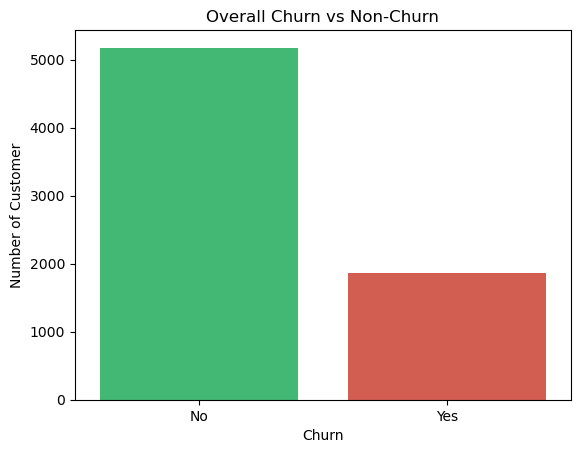

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [90]:
sns.countplot(x = 'churn', data = df ,palette= ['#2ecc71', '#e74c3c'])
plt.title('Overall Churn vs Non-Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Customer')
plt.show()


churn_rate = df['churn'].value_counts(normalize= True) *100
churn_rate


## 2 .Contract Type vs Churn

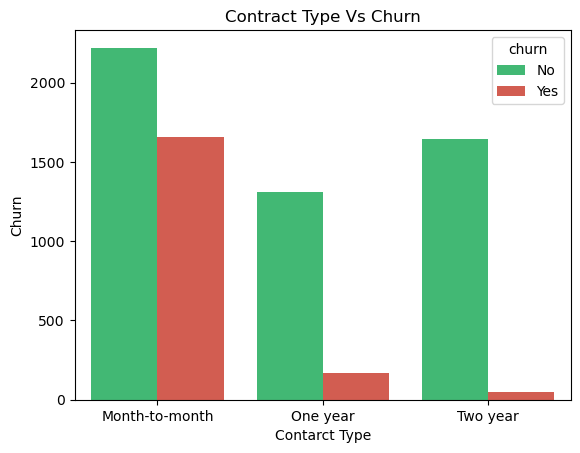

contract        churn
Month-to-month  No       57.3
                Yes      42.7
One year        No       88.7
                Yes      11.3
Two year        No       97.2
                Yes       2.8
Name: proportion, dtype: float64

In [91]:
sns.countplot(x = 'contract',hue ='churn',data = df ,palette=['#2ecc71', '#e74c3c'])
plt.title('Contract Type Vs Churn')
plt.xlabel('Contarct Type')
plt.ylabel('Churn')
plt.show()


df.groupby('contract')['churn'].value_counts(normalize=True).mul(100).round(1)

## 3. Tenure vs Churn

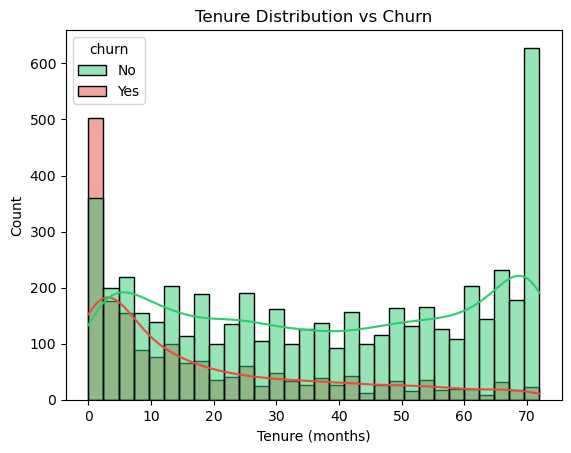

In [92]:
sns.histplot(data = df ,x='tenure',hue ='churn',bins = 30,kde = True, palette= ['#2ecc71', '#e74c3c'] )
plt.title('Tenure Distribution vs Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.show()


## 4. Monthly Charges vs Chur

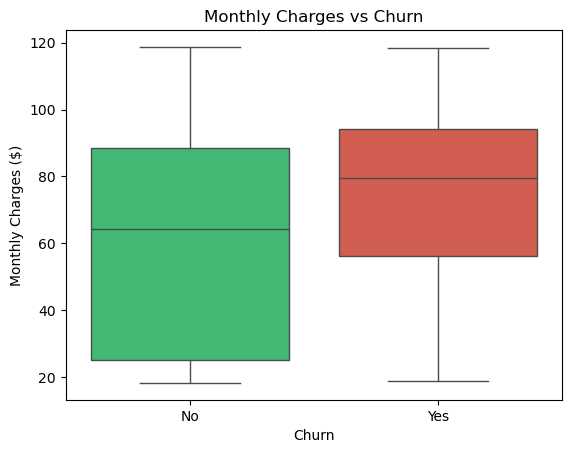

In [93]:
sns.boxplot(data =df , x = 'churn',y = 'monthly_charges',palette=['#2ecc71', '#e74c3c'])

plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()

## 5.Tenure Group vs Churn %

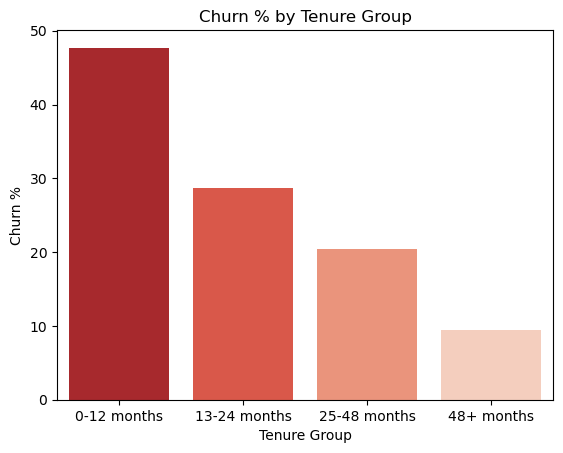

In [94]:

tenure_churn = df.groupby('tenure_group')['churn'].apply(lambda x: (x == 'Yes').mean() *100).reset_index().round(1)
tenure_churn
sns.barplot(x='tenure_group', y='churn',
            data=tenure_churn, palette='Reds_r')
plt.title('Churn % by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn %')
plt.show()


## 6.Internet Service vs Churn

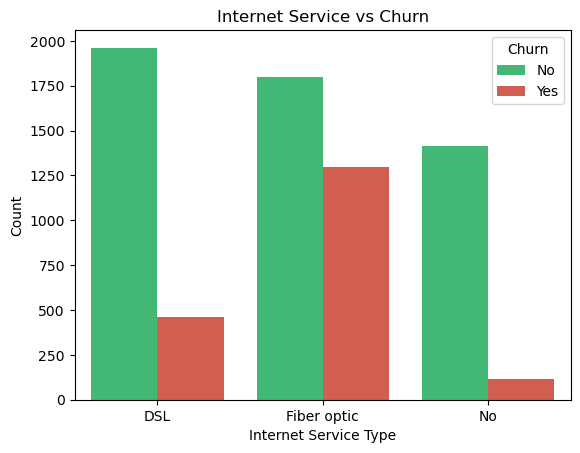

In [95]:
sns.countplot(x='internet_service', hue='churn', data=df,
              palette=['#2ecc71', '#e74c3c'])
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service Type')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.show()

## 7. Correlation Heatmap

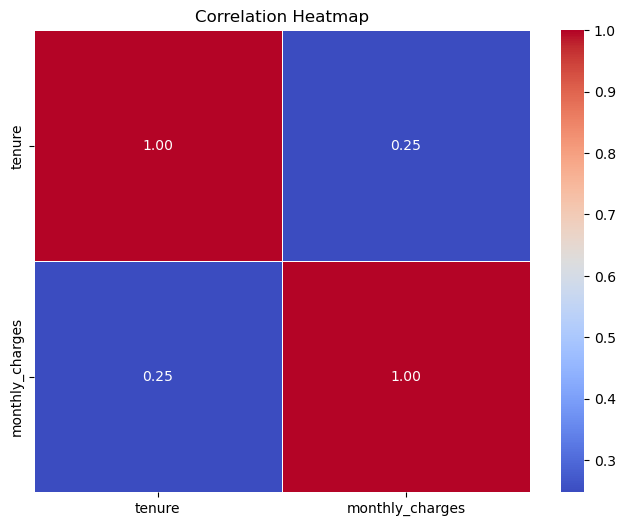

In [96]:
plt.rcParams['figure.figsize'] = (8,6)

num_df = df.select_dtypes(include='number')

sns.heatmap(num_df.corr() ,annot = True,fmt = '.2f' ,cmap ='coolwarm',linewidths = 0.5)

plt.title('Correlation Heatmap')
plt.show()